In [37]:
import sqlite3

def update_experiment_view(db_path='../cem_results.db'):
    """
    Drops the existing experiment_summary view and recreates it 
    with the updated metrics schema including the testset column.
    """
    # Define the SQL script
    sql_script = """
    DROP VIEW IF EXISTS experiment_summary;

    CREATE VIEW experiment_summary AS
    SELECT 
        r.dataset,
        r.entity, 
        r.model_type,
        r.train_size, 
        r.seed, 
        r.lm,
        m.pollution, 
        m.iteration, 
        m.testset,
        m.f1_score,
        m.precision,
        m.recall,
        m.is_final,
        r.run_id,
        r.timestamp
    FROM metrics m
    JOIN runs r ON m.run_id = r.run_id;
    """

    try:
        # Establish connection
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        # Execute the script (handles multiple statements)
        cursor.executescript(sql_script)
        
        conn.commit()
        print("View 'experiment_summary' has been updated successfully.")
        
    except sqlite3.Error as e:
        print(f"An error occurred: {e}")
        
    finally:
        if conn:
            conn.close()



In [38]:
import pandas as pd
update_experiment_view()
def run_sql_query(query: str)-> pd.DataFrame:
    conn = sqlite3.connect('../cem_results.db')


    try:
    
        # Execute and load into DataFrame
        df = pd.read_sql_query(query, conn)

    finally:
        conn.close()
    return df

View 'experiment_summary' has been updated successfully.


In [ ]:
def get_metrics(dataset):
    select_runs = f"""
            SELECT * FROM runs WHERE dataset = '{dataset}' ORDER BY run_id desc 
        """

    df = run_sql_query(select_runs)

    #display(df)
    unique_run_ids = df["run_id"].unique()

    metrics_all = {}
    # iterate over every run 
    for run_id in unique_run_ids: 
        metrics = {}
        # get all metrics associated to this run
        select_metrics = f"""
            SELECT * FROM metrics WHERE run_id = '{run_id}'
        """
    df = run_sql_query(select_metrics)

    # iterate over all entities for this run
    unique_entity_names = df["entity"].unique()
    for entity in unique_entity_names:
        metrics[entity] = {}
        baseline = df.loc[(df["run_id"] == run_id) & (df["dataset"] == "baseline") & (df["entity"] == entity)]
        baseline.drop(columns=["run_id", "entity", "iteration", "is_final"], inplace=True)
        metrics[entity]["baseline"] = baseline.to_dict()

        phase1 = df.loc[(df["run_id"] == run_id) & (df["testset"] == "phase1") & (df["entity"] == entity)]
        phase1.drop(columns=["run_id", "entity", "iteration", "is_final", "testset"], inplace=True)
        metrics[entity]["phase1"] = phase1.to_dict()

        phase2 = df.loc[(df["run_id"] == run_id) & (df["testset"] == "phase2") & (df["entity"] == entity)]
        phase2.drop(columns=["run_id", "entity", "iteration", "is_final", "testset"], inplace=True)
        metrics[entity]["phase2"] = phase2.to_dict()

        matching = {}
        amount_iterations = df["iteration"].unique()
        for iteration in amount_iterations:
            iteration_results = df.loc[(df["run_id"] == run_id) & (df["testset"] == "test") & (df["entity"] == entity) & (df["iteration"] == iteration)]
            iteration_results.drop(columns=["run_id", "entity", "iteration", "is_final", "testset"], inplace=True)
            matching[iteration] = iteration_results.to_dict()
        metrics[entity]["matching"] = matching

    metrics_all[run_id] = metrics
    return metrics_all



In [ ]:
SELECT * FROM metrics WHERE run_id LIKE '9771693_%' LIMIT 100

In [40]:
import pandas as pd
import numpy as np
from rich.console import Console
from rich.table import Table

# 1. Flatten the nested dictionary into a list of observations
data_rows = []
metrics_all = get_metrics("imdb")
for run_id, entities in metrics_all.items():
    for entity_name, phases in entities.items():
        for phase_name, phase_content in phases.items():
            
            # Handle 'matching' iterations
            if phase_name == "matching":
                for iteration_id, iter_metrics in phase_content.items():
                    f1_data = iter_metrics.get("f1_score", {})
                    for val in f1_data.values():
                        data_rows.append({
                            "entity": entity_name,
                            "phase": f"matching_iter_{iteration_id}",
                            "f1_score": val
                        })
            
            # Handle standard phases (baseline, phase1, phase2)
            else:
                f1_data = phase_content.get("f1_score", {})
                for val in f1_data.values():
                    # Only add if a score actually exists (skips empty {} phases)
                    if val is not None:
                        data_rows.append({
                            "entity": entity_name,
                            "phase": phase_name,
                            "f1_score": val
                        })

# 2. Convert to DataFrame
df = pd.DataFrame(data_rows)

# 3. Group by Entity and Phase to calculate Mean and Standard Deviation
# We use ddof=1 for the sample standard deviation (Bessel's correction)
stats_df = df.groupby(["entity", "phase"])["f1_score"].agg(["mean", "std", "count"]).reset_index()

# Rename columns for clarity
stats_df.columns = ["Entity", "Phase", "Mean F1", "Std Dev", "Sample Size (N)"]

# 4. Display the results using a Rich Table
console = Console()
table = Table(title="Aggregated F1 Metrics Across All Runs")

table.add_column("Entity", style="cyan")
table.add_column("Phase", style="magenta")
table.add_column("Mean F1", justify="right", style="green")
table.add_column("Std Dev", justify="right", style="yellow")
table.add_column("Runs (N)", justify="center")

for _, row in stats_df.iterrows():
    # Handle NaN for Std Dev if only 1 run exists
    std_val = f"{row['Std Dev']:.4f}" if pd.notnull(row['Std Dev']) else "N/A"
    
    table.add_row(
        row["Entity"],
        row["Phase"],
        f"{row['Mean F1']:.4f}",
        std_val,
        str(int(row['Sample Size (N)']))
    )

console.print(table)

# Optional: Save summary to CSV
stats_df.to_csv("f1_summary_stats.csv", index=False)

# Convert the summary dataframe to LaTeX code
latex_code = stats_df.to_latex(
    index=False, 
    caption="Summary of F1 Scores across Multiple Runs",
    label="tab:f1_results",
    float_format="%.4f"
)

print(latex_code)

KeyError: 'testset'

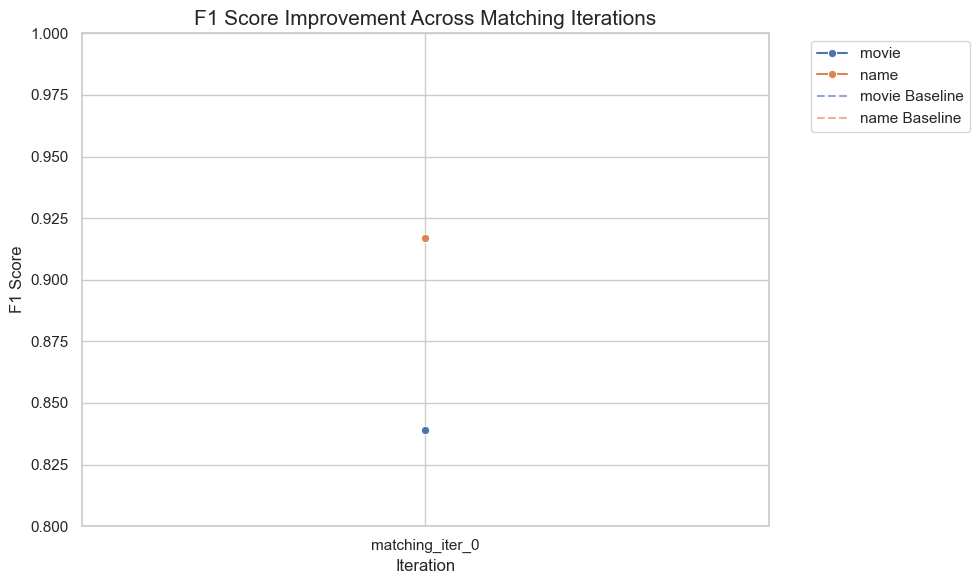

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clean the data for plotting
# We want to separate 'baseline' from 'matching' iterations for a cleaner look
plot_df = df.copy()

# 2. Setup the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create the Line Plot
# Seaborn's lineplot automatically calculates mean and 
# shaded error bands if multiple runs exist for each phase
ax = sns.lineplot(
    data=plot_df[plot_df['phase'].str.contains('matching')], 
    x="phase", 
    y="f1_score", 
    hue="entity", 
    marker="o",
    err_style="band", # This creates the shaded standard deviation
    errorbar="sd"     # Tells it to use Standard Deviation for the band
)

# 4. Add the Baseline as a horizontal dashed line for comparison
for i, entity in enumerate(plot_df['entity'].unique()):
    baseline_val = plot_df[(plot_df['entity'] == entity) & (plot_df['phase'] == 'baseline')]['f1_score'].mean()
    plt.axhline(baseline_val, ls='--', color=sns.color_palette()[i], alpha=0.6, label=f"{entity} Baseline")

# 5. Formatting for the Advisor
plt.title("F1 Score Improvement Across Matching Iterations", fontsize=15)
plt.ylabel("F1 Score")
plt.xlabel("Iteration")
plt.ylim(0.8, 1.0) # Adjust based on your actual score range
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig("experiment_results.png", dpi=300)
plt.show()

In [ ]:
# Check latest runs 



import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Connection
conn = sqlite3.connect('../cem_results.db')
update_experiment_view()

run_id = '9764503_1'

try:
    summary_query = f"""
        SELECT * FROM metrics WHERE run_id = '{run_id}' AND testset = 'test' ORDER BY "entity" desc 
    """
    
    # Execute and load into DataFrame
    df = pd.read_sql_query(summary_query, conn)

    df_filtered = df.drop(columns=['num_pairs'])
    display(df_filtered)

finally:
    conn.close()

# print(df_baseline.to_csv())

View 'experiment_summary' has been updated successfully.


,run_id,entity,pollution,iteration,is_final,testset,precision,recall,f1_score,runtime
0,9764503_1,name,high,0,1,test,0.951,0.889,0.919,250.958722
1,9764503_1,name,high,0,0,test,0.898,0.908,0.903,311.596046
2,9764503_1,name,high,1,0,test,0.927,0.962,0.944,309.880043
3,9764503_1,name,high,2,0,test,0.926,0.984,0.954,307.264294
4,9764503_1,name,high,3,1,test,0.928,0.978,0.952,308.923234
5,9764503_1,movie,high,0,1,test,0.972,0.724,0.830,304.087931
6,9764503_1,movie,high,0,0,test,0.941,0.812,0.872,156.890042
7,9764503_1,movie,high,1,0,test,0.942,0.879,0.909,157.064679
8,9764503_1,movie,high,2,0,test,0.942,0.882,0.911,156.398656
9,9764503_1,movie,high,3,1,test,0.941,0.893,0.917,154.381178


# Check per Run_ID

In [ ]:


import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Connection
conn = sqlite3.connect('../cem_results.db')
update_experiment_view()

run_id = '9764503_1'

try:
    summary_query = f"""
        SELECT * FROM metrics WHERE run_id = '{run_id}' AND testset = 'test' ORDER BY "entity" desc 
    """
    
    # Execute and load into DataFrame
    df = pd.read_sql_query(summary_query, conn)

    df_filtered = df.drop(columns=['num_pairs'])
    display(df_filtered)

finally:
    conn.close()

# print(df_baseline.to_csv())

View 'experiment_summary' has been updated successfully.


,run_id,entity,pollution,iteration,is_final,testset,precision,recall,f1_score,runtime
0,9764503_1,name,high,0,1,test,0.951,0.889,0.919,250.958722
1,9764503_1,name,high,0,0,test,0.898,0.908,0.903,311.596046
2,9764503_1,name,high,1,0,test,0.927,0.962,0.944,309.880043
3,9764503_1,name,high,2,0,test,0.926,0.984,0.954,307.264294
4,9764503_1,name,high,3,1,test,0.928,0.978,0.952,308.923234
5,9764503_1,movie,high,0,1,test,0.972,0.724,0.830,304.087931
6,9764503_1,movie,high,0,0,test,0.941,0.812,0.872,156.890042
7,9764503_1,movie,high,1,0,test,0.942,0.879,0.909,157.064679
8,9764503_1,movie,high,2,0,test,0.942,0.882,0.911,156.398656
9,9764503_1,movie,high,3,1,test,0.941,0.893,0.917,154.381178


In [ ]:


import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Connection
conn = sqlite3.connect('../cem_results.db')
update_experiment_view()

try:
    summary_query = f"""
        SELECT * FROM experiment_summary  ORDER BY "timestamp"  desc 
    """
    
    # Execute and load into DataFrame
    df = pd.read_sql_query(summary_query, conn)

    df_filtered = df.drop(columns=["dataset", "lm", "testset", "is_final", "run_id", "timestamp"])
    display(df_filtered)

finally:
    conn.close()

# print(df_baseline.to_csv())

View 'experiment_summary' has been updated successfully.


,entity,model_type,train_size,seed,pollution,iteration,f1_score,precision,recall
0,2026-04-16 15:30:47,baseline,1.0,30,high,0,0.839,0.953,0.749
1,2026-04-16 15:30:47,baseline,1.0,30,high,0,0.917,0.953,0.883
2,2026-04-16 16:17:39,baseline,1.0,30,high,0,0.830,0.972,0.724
3,2026-04-16 16:32:16,1,1.0,30,high,0,0.830,0.972,0.724
4,2026-04-16 16:17:39,baseline,1.0,20,high,0,0.830,0.972,0.724
...,...,...,...,...,...,...,...,...,...
2917,track,baseline,1.0,10,high,3,0.979,0.979,0.979
2918,track,baseline,1.0,20,high,3,0.733,0.578,1.000
2919,track,baseline,1.0,10,high,3,0.648,0.485,0.976
2920,track,baseline,1.0,10,high,3,0.944,0.899,0.994


In [ ]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Connection
conn = sqlite3.connect('../cem_results.db')
update_experiment_view()

target_entity = "movie"
target_size = 1.0
target_seed = 42
target_pollution = "high"


try:

    summary_query = f"""
        SELECT * FROM experiment_summary 
        WHERE entity = '{target_entity}' AND
        train_size = '{target_size}' AND

        pollution = '{target_pollution}'
        ORDER BY "timestamp" DESC
    """
    
    # Execute and load into DataFrame
    df_results = pd.read_sql_query(summary_query, conn)
    display(df_results)

finally:
    conn.close()


results_filtered = df_results.drop(columns=["dataset", "model_type", "lm", "testset", "is_final", "run_id", "timestamp"])
print(results_filtered.to_csv())

View 'experiment_summary' has been updated successfully.


,dataset,entity,model_type,train_size,seed,lm,pollution,iteration,testset,f1_score,precision,recall,is_final,run_id,timestamp


,entity,train_size,seed,pollution,iteration,f1_score,precision,recall



In [ ]:


import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Connection
conn = sqlite3.connect('../cem_results.db')
update_experiment_view()

try:
    summary_query = f"""
        SELECT * FROM experiment_summary WHERE model_type = 'baseline' ORDER BY "timestamp"  desc LIMIT 20
    """
    
    # Execute and load into DataFrame
    df_baseline = pd.read_sql_query(summary_query, conn)

    baseline_filtered = df_baseline.drop(columns=["dataset", "lm", "testset", "is_final", "run_id", "timestamp"])
    display(baseline_filtered)

finally:
    conn.close()

# print(df_baseline.to_csv())

View 'experiment_summary' has been updated successfully.


,entity,model_type,train_size,seed,pollution,iteration,f1_score,precision,recall
0,2026-04-16 15:30:47,baseline,1.0,30,high,0,0.839,0.953,0.749
1,2026-04-16 15:30:47,baseline,1.0,30,high,0,0.917,0.953,0.883
2,2026-04-16 16:17:39,baseline,1.0,30,high,0,0.830,0.972,0.724
3,2026-04-16 16:17:39,baseline,1.0,20,high,0,0.830,0.972,0.724
4,2026-04-16 16:17:39,baseline,1.0,10,high,0,0.830,0.972,0.724
5,2026-04-16 16:17:39,baseline,1.0,30,high,0,0.919,0.951,0.889
6,2026-04-16 16:17:39,baseline,1.0,20,high,0,0.919,0.951,0.889
7,2026-04-16 16:17:39,baseline,1.0,10,high,0,0.919,0.951,0.889
8,2026-04-16 16:17:39,baseline,1.0,30,high,0,0.882,0.961,0.815
9,2026-04-16 16:17:39,baseline,1.0,20,high,0,0.870,0.933,0.815


In [ ]:
target_entity = "movie"
target_size = 1.0
target_seed = 42
target_pollution = "high"

# Filter the dataframe
mask = (
    # (results_filtered["entity"] == target_entity) &
    (results_filtered["train_size"] == target_size) &
    (results_filtered["seed"] == target_seed) &
    (results_filtered["pollution"] == target_pollution)
)

display(results_filtered[mask])

# Filter the dataframe
mask = (
    # (results_filtered["entity"] == target_entity) &
    (baseline_filtered["train_size"] == target_size) &
    (baseline_filtered["seed"] == target_seed) &
    (baseline_filtered["pollution"] == target_pollution)
)

display(baseline_filtered[mask])



import pandas as pd

# Define the columns to match on
match_cols = ["train_size", "seed", "pollution", "entity"]

# Perform an inner join to align the rows
df_comparison = pd.merge(
    df_results, 
    df_baseline, 
    on=match_cols, 
    suffixes=('_res', '_base')
)

display(df_comparison)
# Now you can calculate differences, for example:
df_comparison['score_diff'] = df_comparison['f1_score_res'] - df_comparison['f1_score_base']
display(df_comparison)

,entity,train_size,seed,pollution,iteration,f1_score,precision,recall


,entity,model_type,train_size,seed,pollution,iteration,f1_score,precision,recall


,dataset_res,entity,model_type_res,train_size,seed,lm_res,pollution,iteration_res,testset_res,f1_score_res,...,model_type_base,lm_base,iteration_base,testset_base,f1_score_base,precision_base,recall_base,is_final_base,run_id_base,timestamp_base


,dataset_res,entity,model_type_res,train_size,seed,lm_res,pollution,iteration_res,testset_res,f1_score_res,...,lm_base,iteration_base,testset_base,f1_score_base,precision_base,recall_base,is_final_base,run_id_base,timestamp_base,score_diff
